# Capstone Project - EDA: Ames Housing (House Prices)
## Giá trị thiếu, mẫu bất thường & ngoại lệ


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df = pd.read_csv('train.csv')
df.shape

(1460, 81)

## 1. Kiểm tra bản ghi trùng lặp

In [2]:
print("Số bản ghi trùng lặp (toàn bộ cột):", df.duplicated().sum())
print("Số Id trùng lặp:", df['Id'].duplicated().sum())

So ban ghi trung lap (toan bo cot): 0
So Id trung lap: 0


**Nhận xét:** Không có bản ghi trùng lặp. Mỗi dòng tương ứng với một giao dịch nhà riêng biệt và `Id` là mã duy nhất trong tập dữ liệu.

## 2. Phân tích giá trị thiếu (missing values)

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({'so_luong_thieu': missing, 'ty_le_%': missing_pct})
print(f"Số cột có giá trị thiếu: {len(missing_table)} / {df.shape[1]}")
missing_table

So cot co gia tri thieu: 19 / 81


,so_luong_thieu,ty_le_%
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


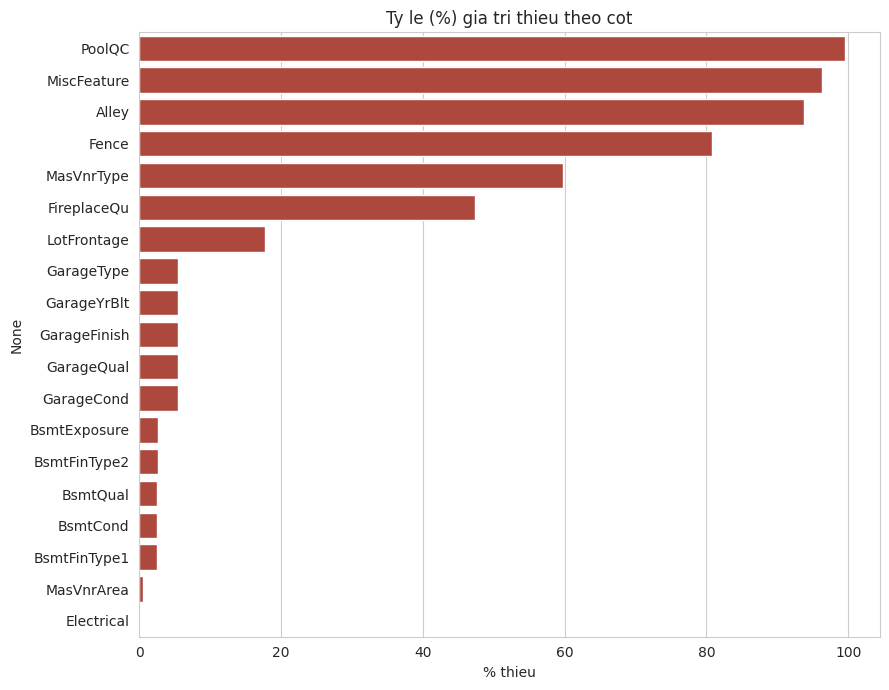

In [4]:
plt.figure(figsize=(9,7))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color='#c0392b')
plt.title('Tỷ lệ (%) giá trị thiếu theo cột')
plt.xlabel('% thiếu')
plt.tight_layout()
plt.show()

**Nhận xét:**
- 5 cột thiếu nhiều nhất là: **PoolQC (99.5%)**, **MiscFeature (96.3%)**, **Alley (93.8%)**, **Fence (80.8%)**, **MasVnrType (59.7%)**.
- Theo `data_description.txt`, đây không hẳn là dữ liệu bị mất ngẫu nhiên. Giá trị NaN ở nhiều cột có nghĩa là **không có đặc điểm đó** (ví dụ: nhà không có hồ bơi, không có hàng rào, không có lối đi phụ...). Đây là dạng **missing có cấu trúc (structural missing)**, nên có thể điền `None`/`No` thay vì xóa cột hoặc điền giá trị trung bình một cách máy móc.
- Các cột liên quan đến **Garage** (`GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageQual`, `GarageCond` khoảng 5.5%) và **Basement** (`BsmtExposure`, `BsmtFinType1/2`, `BsmtQual`, `BsmtCond` khoảng 2.5%) thường thiếu cùng trên một nhóm bản ghi. Điều này phù hợp với trường hợp nhà **không có garage / không có basement**, chứ không nhất thiết là lỗi thu thập dữ liệu.
- `LotFrontage` thiếu **17.7%**, đây là trường hợp có thể điền theo giá trị median của từng `Neighborhood` vì mặt tiền lô đất có liên quan đến vị trí.
- `Electrical` chỉ thiếu 1 dòng (0.1%), có thể xem là một trường hợp thiếu dữ liệu đơn lẻ.


## 3. Phát hiện ngoại lệ (outliers) bằng boxplot và IQR

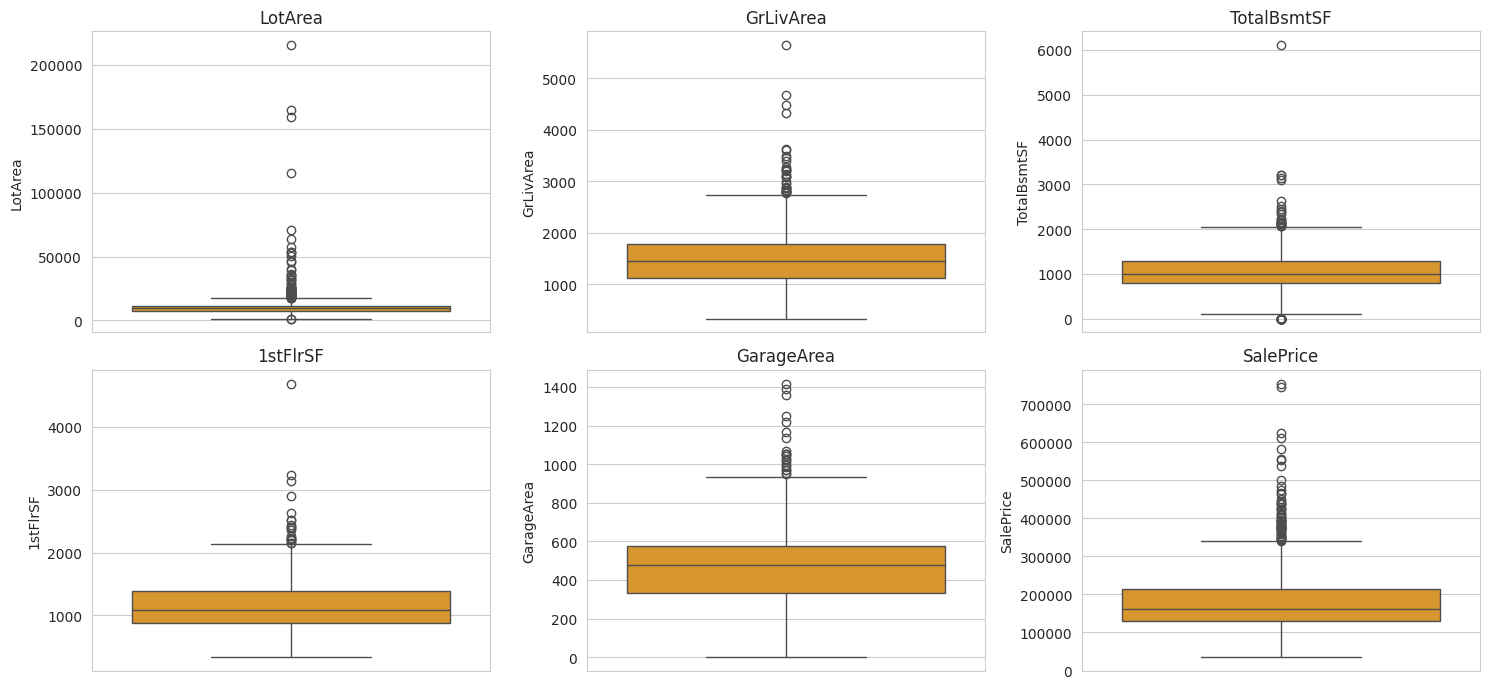

In [5]:
key_num_cols = ['LotArea','GrLivArea','TotalBsmtSF','1stFlrSF','GarageArea','SalePrice']
fig, axes = plt.subplots(2, 3, figsize=(15,7))
for ax, col in zip(axes.flatten(), key_num_cols):
    sns.boxplot(y=df[col], ax=ax, color='#f39c12')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [6]:
def iqr_outlier_summary(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return n_out, round(n_out/len(series)*100, 2), round(lower,1), round(upper,1)

rows = []
for col in key_num_cols:
    n, pct, low, up = iqr_outlier_summary(df[col])
    rows.append([col, n, pct, low, up])
iqr_table = pd.DataFrame(rows, columns=['Cot','So_outlier_IQR','Ty_le_%','Nguong_duoi','Nguong_tren'])
iqr_table

,Cot,So_outlier_IQR,Ty_le_%,Nguong_duoi,Nguong_tren
0,LotArea,69,4.73,1481.5,17673.5
1,GrLivArea,31,2.12,158.6,2747.6
2,TotalBsmtSF,61,4.18,42.0,2052.0
3,1stFlrSF,20,1.37,118.1,2155.1
4,GarageArea,21,1.44,-27.8,938.2
5,SalePrice,61,4.18,3937.5,340037.5


**Nhận xét:** Theo phương pháp IQR, `LotArea` và `SalePrice` có tỷ lệ giá trị nằm ngoài ngưỡng thống kê tương đối cao. Tuy nhiên, trong dữ liệu nhà đất, nhiều giá trị như vậy vẫn có thể là **giá trị hợp lệ nhưng hiếm** (ví dụ nhà rất rộng hoặc giá bán rất cao), nên không nên loại bỏ chỉ dựa vào IQR mà cần xem xét từng trường hợp.


## 4. Mẫu bất thường được chính tác giả paper lưu ý: GrLivArea lớn nhưng SalePrice thấp

In [7]:
anomaly = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print("Số bản ghi bất thường:", len(anomaly))
anomaly[['Id','GrLivArea','TotalBsmtSF','OverallQual','SalePrice']]

So ban ghi bat thuong: 2


,Id,GrLivArea,TotalBsmtSF,OverallQual,SalePrice
523,524,4676,3138,10,184750
1298,1299,5642,6110,10,160000


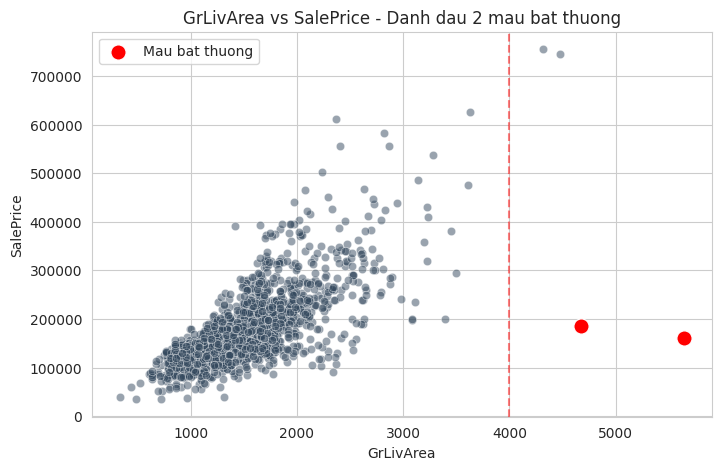

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, alpha=0.5, color='#34495e')
sns.scatterplot(x='GrLivArea', y='SalePrice', data=anomaly, color='red', s=120, label='Mẫu bất thường')
plt.axvline(4000, color='red', linestyle='--', alpha=0.5)
plt.title('GrLivArea và SalePrice - Đánh dấu 2 mẫu bất thường')
plt.legend()
plt.show()

**Nhận xét:** Có **2 bản ghi trong file train Kaggle (Id 524 và Id 1299)** có `GrLivArea > 4000` và `SalePrice` thấp bất thường so với xu hướng chung. Đây là những điểm dữ liệu cần được xem xét riêng trước khi xây dựng mô hình hồi quy.


## 4.1. Đối chiếu mẫu có GrLivArea lớn với paper

Paper của De Cock sử dụng bộ dữ liệu Ames đầy đủ **2930 quan sát**. Tác giả lưu ý có **5 quan sát** có diện tích sinh hoạt trên **4000 sqft**; trong đó 3 quan sát được mô tả là true outliers và 2 quan sát là các giao dịch bất thường. Tác giả khuyến nghị loại các nhà có `GrLivArea > 4000` trước khi giao bộ dữ liệu cho sinh viên.


In [ ]:
large_area = df[df['GrLivArea'] > 4000][['Id', 'GrLivArea', 'OverallQual', 'SalePrice']].sort_values('GrLivArea', ascending=False)

print("Các mẫu trong file train Kaggle có GrLivArea > 4000:")
display(large_area)
print("Số mẫu trong file train Kaggle:", len(large_area))


**Nhận xét bổ sung:** Trong file `train.csv` của Kaggle đang sử dụng, có **2 mẫu** có `GrLivArea > 4000`, là hai dòng đã được kiểm tra ở phần trên. Con số 2 này là kết quả của **tập train Kaggle**, không phải tổng số 5 quan sát trong bộ dữ liệu đầy đủ của paper. Vì hai nguồn dữ liệu khác nhau nên không nên nói rằng paper chỉ ra đúng 2 mẫu theo các `Id` của Kaggle.

Ngoài ra, khi nhận xét nguyên nhân của một giao dịch bất thường, nên dựa vào thông tin có trong dữ liệu hoặc paper, tránh khẳng định thêm những nguyên nhân chưa được kiểm chứng.


## 5. Kết luận

- Dữ liệu **không có bản ghi trùng lặp**.
- **19/81 cột** có giá trị thiếu; phần lớn là **missing có cấu trúc** (NaN = "không có đặc điểm đó"), nên có thể điền `None`/`No` hoặc 0 tùy theo ý nghĩa của biến thay vì xóa cột hay điền trung bình một cách máy móc. Riêng `LotFrontage` có thể điền theo median của `Neighborhood`.
- Trong file train Kaggle có **2 bản ghi có `GrLivArea > 4000`** (Id 524 và 1299) cần được xem xét riêng. Khi đối chiếu với paper, cần phân biệt 2 mẫu trong train Kaggle với 5 quan sát trong bộ dữ liệu Ames đầy đủ.
